# Imports

In [1]:
from Fcts_Base import get_stainings, find_zarr_dirs, extract_ome_zarr_tables
from Fcts_FE import make_experiment, estimate_staining_thresholds, threshold_change, plot_thresholds, test_skeletonization, extract_features
from Fcts_Plotting import segmentation_fidelity_check

# User Input

### General Settings

Provide information regarding directories, used barcodes, and define the file name for results.
Setup .xls file must be in source folder. See GitHub readme for more information.

In [2]:
# Point to experiment folder. Has to include setup .xls file.
source = "/tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis"

# Optional: Analysis directory. If None this will default to the source folder. Creates 4 folder substructure for standardization in subsequent notebooks.
analysis_dir = None

### Measurement settings

In [3]:
quantiles_to_calc = [0.01, 0.25, 0.50, 0.75, 0.99] # List of quantiled to be calculated during feature extraction for every staining.

pyramid_level = 0 # Fractal pyramid level to use for feature extraction.

table_name = "organoids_ROI_table" # Fractal ROI table name to load images.

label_name = "organoids" # Fractal label name to load segmentation.

# Load files and display experimental setup
Loads information from .xls setup files to subsequently link them to features of extracted organoids. Will display setup of all found imaging plates, with each well showing information regarding its conditions in the format of [Medium condition, used antibody mix, used cell line, additional condition]

In [4]:
stainings = get_stainings(source)

Found 2 staining mixes in experiment setup:
  AB1: DAPI, KRT7, AQP5
  AB2: DAPI, MIST1, KI67, aSMA
For mix AB1, add 9.52 ul DAPI-405 (ATMC Freezer 1), 47.61 ul AQP5-AF647 (ATMC), 47.61 ul KRT7-AF488 (ATMC) into 9522 ul staining solution.
For mix AB2, add 9.52 ul DAPI-405 (ATMC Freezer 1), 95.22 ul MIST1 (ATMC), 47.61 ul KI67 (Liberali), 9.52 ul aSMA-AF647 (ATMC), 19.04 ul aMouse-AF568 (ATMC Fridge 1), 19.04 ul aRabbit-AF488+ (ATMC Fridge 1) into 9522 ul staining solution.


In [5]:
folder = find_zarr_dirs(source) # Find ome_zarr files in source folder.
experiment_setup, barcodes = make_experiment(source) # Create experiment setup from Layout in source folder.

if analysis_dir is None:
    analysis_dir = source

Found 2 OME-Zarr directories in /tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis at depth 2.
Directories found. Make sure that variable barcodes is in the same order:
- /tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/0_Data/raw/08-06-1.zarr
- /tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/0_Data/raw/08-06-4.zarr


Plate-Barcode: 08-06-1


,03,04,05,06,07,08,09,10,11,12,13,14,15,16,17,18,19,20,21,22
E,"[Ctrl, AB1, SGO, D4]","[Ctrl, AB1, SGO, D4]","[Ctrl, AB1, SGO, D4]","[Ctrl, AB2, SGO, D4]","[Ctrl, AB2, SGO, D4]","[Ctrl, AB2, SGO, D4]","[atRA, AB1, SGO, D4]","[atRA, AB1, SGO, D4]","[atRA, AB1, SGO, D4]","[atRA, AB2, SGO, D4]","[atRA, AB2, SGO, D4]","[atRA, AB2, SGO, D4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F,"[-RSPO1, AB1, SGO, D4]","[-WNT, AB1, SGO, D4]","[-NRG1, AB1, SGO, D4]","[-NAC, AB1, SGO, D4]","[-A83, AB1, SGO, D4]","[-IGF1, AB1, SGO, D4]","[-FGF2, AB1, SGO, D4]","[-Noggin, AB1, SGO, D4]","[-IGF1-Noggin, AB1, SGO, D4]","[FBS+HGF, AB1, SGO, D4]","[FBS+HGF+DAPT, AB1, SGO, D4]","[-FGF2+FGF1, AB1, SGO, D4]","[-FGF2+FGF7, AB1, SGO, D4]","[-FGF2+FGF10, AB1, SGO, D4]","[aDMEM, AB1, SGO, D4]","[Jeon, AB1, SGO, D4]","[Jeon-FGF10, AB1, SGO, D4]","[JeonDMEM, AB1, SGO, D4]","[Jeon+atRA, AB1, SGO, D4]","[Pringle, AB1, SGO, D4]"
G,"[-RSPO1, AB1, SGO, D4]","[-WNT, AB1, SGO, D4]","[-NRG1, AB1, SGO, D4]","[-NAC, AB1, SGO, D4]","[-A83, AB1, SGO, D4]","[-IGF1, AB1, SGO, D4]","[-FGF2, AB1, SGO, D4]","[-Noggin, AB1, SGO, D4]","[-IGF1-Noggin, AB1, SGO, D4]","[FBS+HGF, AB1, SGO, D4]","[FBS+HGF+DAPT, AB1, SGO, D4]","[-FGF2+FGF1, AB1, SGO, D4]","[-FGF2+FGF7, AB1, SGO, D4]","[-FGF2+FGF10, AB1, SGO, D4]","[aDMEM, AB1, SGO, D4]","[Jeon, AB1, SGO, D4]","[Jeon-FGF10, AB1, SGO, D4]","[JeonDMEM, AB1, SGO, D4]","[Jeon+atRA, AB1, SGO, D4]","[Pringle, AB1, SGO, D4]"
H,"[-RSPO1, AB1, SGO, D4]","[-WNT, AB1, SGO, D4]","[-NRG1, AB1, SGO, D4]","[-NAC, AB1, SGO, D4]","[-A83, AB1, SGO, D4]","[-IGF1, AB1, SGO, D4]","[-FGF2, AB1, SGO, D4]","[-Noggin, AB1, SGO, D4]","[-IGF1-Noggin, AB1, SGO, D4]","[FBS+HGF, AB1, SGO, D4]","[FBS+HGF+DAPT, AB1, SGO, D4]","[-FGF2+FGF1, AB1, SGO, D4]","[-FGF2+FGF7, AB1, SGO, D4]","[-FGF2+FGF10, AB1, SGO, D4]","[aDMEM, AB1, SGO, D4]","[Jeon, AB1, SGO, D4]","[Jeon-FGF10, AB1, SGO, D4]","[JeonDMEM, AB1, SGO, D4]","[Jeon+atRA, AB1, SGO, D4]","[Pringle, AB1, SGO, D4]"
I,"[-RSPO1, AB2, SGO, D4]","[-WNT, AB2, SGO, D4]","[-NRG1, AB2, SGO, D4]","[-NAC, AB2, SGO, D4]","[-A83, AB2, SGO, D4]","[-IGF1, AB2, SGO, D4]","[-FGF2, AB2, SGO, D4]","[-Noggin, AB2, SGO, D4]","[-IGF1-Noggin, AB2, SGO, D4]","[FBS+HGF, AB2, SGO, D4]","[FBS+HGF+DAPT, AB2, SGO, D4]","[-FGF2+FGF1, AB2, SGO, D4]","[-FGF2+FGF7, AB2, SGO, D4]","[-FGF2+FGF10, AB2, SGO, D4]","[aDMEM, AB2, SGO, D4]","[Jeon, AB2, SGO, D4]","[Jeon-FGF10, AB2, SGO, D4]","[JeonDMEM, AB2, SGO, D4]","[Jeon+atRA, AB2, SGO, D4]","[Pringle, AB2, SGO, D4]"
J,"[-RSPO1, AB2, SGO, D4]","[-WNT, AB2, SGO, D4]","[-NRG1, AB2, SGO, D4]","[-NAC, AB2, SGO, D4]","[-A83, AB2, SGO, D4]","[-IGF1, AB2, SGO, D4]","[-FGF2, AB2, SGO, D4]","[-Noggin, AB2, SGO, D4]","[-IGF1-Noggin, AB2, SGO, D4]","[FBS+HGF, AB2, SGO, D4]","[FBS+HGF+DAPT, AB2, SGO, D4]","[-FGF2+FGF1, AB2, SGO, D4]","[-FGF2+FGF7, AB2, SGO, D4]","[-FGF2+FGF10, AB2, SGO, D4]","[aDMEM, AB2, SGO, D4]","[Jeon, AB2, SGO, D4]","[Jeon-FGF10, AB2, SGO, D4]","[JeonDMEM, AB2, SGO, D4]","[Jeon+atRA, AB2, SGO, D4]","[Pringle, AB2, SGO, D4]"
K,"[-RSPO1, AB2, SGO, D4]","[-WNT, AB2, SGO, D4]","[-NRG1, AB2, SGO, D4]","[-NAC, AB2, SGO, D4]","[-A83, AB2, SGO, D4]","[-IGF1, AB2, SGO, D4]","[-FGF2, AB2, SGO, D4]","[-Noggin, AB2, SGO, D4]","[-IGF1-Noggin, AB2, SGO, D4]","[FBS+HGF, AB2, SGO, D4]","[FBS+HGF+DAPT, AB2, SGO, D4]","[-FGF2+FGF1, AB2, SGO, D4]","[-FGF2+FGF7, AB2, SGO, D4]","[-FGF2+FGF10, AB2, SGO, D4]","[aDMEM, AB2, SGO, D4]","[Jeon, AB2, SGO, D4]","[Jeon-FGF10, AB2, SGO, D4]","[JeonDMEM, AB2, SGO, D4]","[Jeon+atRA, AB2, SGO, D4]","[Pringle, AB2, SGO, D4]"




Plate-Barcode: 08-06-4


,03,04,05,06,07,08,09,10,11,12,13,14,15,16,17,18,19
C,"[Ctrl, AB1, SGO, D14]","[-EGF, AB1, SGO, D14]","[-NRG1, AB1, SGO, D14]","[-RSPO1, AB1, SGO, D14]","[-Noggin, AB1, SGO, D14]","[-IGF1, AB1, SGO, D14]","[-FGF2, AB1, SGO, D14]","[-VitA, AB1, SGO, D14]","[-IGF1-Noggin, AB1, SGO, D14]","[FBS+HGF, AB1, SGO, D14]","[FBS+HGF+DAPT, AB1, SGO, D14]","[-FGF2+FGF1, AB1, SGO, D14]","[-FGF2+FGF7, AB1, SGO, D14]","[-FGF2+FGF10, AB1, SGO, D14]","[aDMEM, AB1, SGO, D14]","[atRA-half, AB1, SGO, D14]","[atRA-full, AB1, SGO, D14]"
D,"[Ctrl, AB1, SGO, D14]","[-EGF, AB1, SGO, D14]","[-NRG1, AB1, SGO, D14]","[-RSPO1, AB1, SGO, D14]","[-Noggin, AB1, SGO, D14]","[-IGF1, AB1, SGO, D14]","[-FGF2, AB1, SGO, D14]","[-VitA, AB1, SGO, D14]","[-IGF1-Noggin, AB1, SGO, D14]","[FBS+HGF, AB1, SGO, D14]","[FBS+HGF+DAPT, AB1, SGO, D14]","[-FGF2+FGF1, AB1, SGO, D14]","[-FGF2+FGF7, AB1, SGO, D14]","[-FGF2+FGF10, AB1, SGO, D14]","[aDMEM, AB1, SGO, D14]","[atRA-half, AB1, SGO, D14]","[atRA-full, AB1, SGO, D14]"
E,"[Ctrl, AB1, SGO, D14]","[-EGF, AB1, SGO, D14]","[-NRG1, AB1, SGO, D14]","[-RSPO1, AB1, SGO, D14]","[-Noggin, AB1, SGO, D14]","[-IGF1, AB1, SGO, D14]","[-FGF2, AB1, SGO, D14]","[-VitA, AB1, SGO, D14]","[-IGF1-Noggin, AB1, SGO, D14]","[FBS+HGF, AB1, SGO, D14]","[FBS+HGF+DAPT, AB1, SGO, D14]","[-FGF2+FGF1, AB1, SGO, D14]","[-FGF2+FGF7, AB1, SGO, D14]","[-FGF2+FGF10, AB1, SGO, D14]","[aDMEM, AB1, SGO, D14]","[atRA-half, AB1, SGO, D14]","[atRA-full, AB1, SGO, D14]"
F,"[Ctrl, AB2, SGO, D14]","[-EGF, AB2, SGO, D14]","[-NRG1, AB2, SGO, D14]","[-RSPO1, AB2, SGO, D14]","[-Noggin, AB2, SGO, D14]","[-IGF1, AB2, SGO, D14]","[-FGF2, AB2, SGO, D14]","[-VitA, AB2, SGO, D14]","[-IGF1-Noggin, AB2, SGO, D14]","[FBS+HGF, AB2, SGO, D14]","[FBS+HGF+DAPT, AB2, SGO, D14]","[-FGF2+FGF1, AB2, SGO, D14]","[-FGF2+FGF7, AB2, SGO, D14]","[-FGF2+FGF10, AB2, SGO, D14]","[aDMEM, AB2, SGO, D14]","[atRA-half, AB2, SGO, D14]","[atRA-full, AB2, SGO, D14]"
G,"[Ctrl, AB2, SGO, D14]","[-EGF, AB2, SGO, D14]","[-NRG1, AB2, SGO, D14]","[-RSPO1, AB2, SGO, D14]","[-Noggin, AB2, SGO, D14]","[-IGF1, AB2, SGO, D14]","[-FGF2, AB2, SGO, D14]","[-VitA, AB2, SGO, D14]","[-IGF1-Noggin, AB2, SGO, D14]","[FBS+HGF, AB2, SGO, D14]","[FBS+HGF+DAPT, AB2, SGO, D14]","[-FGF2+FGF1, AB2, SGO, D14]","[-FGF2+FGF7, AB2, SGO, D14]","[-FGF2+FGF10, AB2, SGO, D14]","[aDMEM, AB2, SGO, D14]","[atRA-half, AB2, SGO, D14]","[atRA-full, AB2, SGO, D14]"
H,"[Ctrl, AB2, SGO, D14]","[-EGF, AB2, SGO, D14]","[-NRG1, AB2, SGO, D14]","[-RSPO1, AB2, SGO, D14]","[-Noggin, AB2, SGO, D14]","[-IGF1, AB2, SGO, D14]","[-FGF2, AB2, SGO, D14]","[-VitA, AB2, SGO, D14]","[-IGF1-Noggin, AB2, SGO, D14]","[FBS+HGF, AB2, SGO, D14]","[FBS+HGF+DAPT, AB2, SGO, D14]","[-FGF2+FGF1, AB2, SGO, D14]","[-FGF2+FGF7, AB2, SGO, D14]","[-FGF2+FGF10, AB2, SGO, D14]","[aDMEM, AB2, SGO, D14]","[atRA-half, AB2, SGO, D14]","[atRA-full, AB2, SGO, D14]"
I,"[Jeon, AB1, SGO, D14]","[Jeon-FGF10, AB1, SGO, D14]","[Jeon+DMEM-half, AB1, SGO, D14]","[Jeon+DMEM-full, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Pringle, AB1, SGO, D14]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
J,"[Jeon, AB1, SGO, D14]","[Jeon-FGF10, AB1, SGO, D14]","[Jeon+DMEM-half, AB1, SGO, D14]","[Jeon+DMEM-full, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Pringle, AB1, SGO, D14]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K,"[Jeon, AB1, SGO, D14]","[Jeon-FGF10, AB1, SGO, D14]","[Jeon+DMEM-half, AB1, SGO, D14]","[Jeon+DMEM-full, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Jeon+atRA-half, AB1, SGO, D14]","[Pringle, AB1, SGO, D14]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L,"[Jeon, AB2, SGO, D14]","[Jeon-FGF10, AB2, SGO, D14]","[Jeon+DMEM-half, AB2, SGO, D14]","[Jeon+DMEM-full, AB2, SGO, D14]","[Jeon+atRA-half, AB2, SGO, D14]","[Jeon+atRA-half, AB2, SGO, D14]","[Pringle, AB2, SGO, D14]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Found 2 barcodes in experiment setup:
08-06-1
08-06-4


# Load ome-zarr plates
Uses ez-zarr to load ome-zarr plates as objects for further processing

In [6]:
ome_zarr_dict, ome_zarr_df = extract_ome_zarr_tables(experiment_setup, source, folder, table_name)

# Estimate thresholds

### Automatic estimation
Estimates thresholds in time course experiments automatically by picking 0 random organoids per timepoint (stored in "Other" in the .xls setup file) within the control_condition for all stainings. Subsequently runs a triangle-segmentation on each picked organoid and returns the quantile (q) of this list. Thresholds can be changed by hand subsequently if not fitting.

In [7]:
control_condition = None # Must be key in Medium tab of .xls setup file. Set to None if not applicable.
n = 2 # Number of organoids picked randomly per timepoint
seed = 50 # Random seed
sigma = 1 # Sigma for gaussian blurring
q = 0.5 # Quantile used to pick final threshold

thresholds, dict_org, timepoints_lst = estimate_staining_thresholds(
    ome_zarr_df=ome_zarr_df,
    ome_zarr_dict = ome_zarr_dict, 
    stainings = stainings,
    experiment_setup = experiment_setup,
    table_name = table_name,
    label_name = label_name,
    pyramid_level = pyramid_level,
    control_condition = control_condition,
    n = n,
    seed = seed, 
    sigma = sigma,
    q = q
    )

### Manual change
Optional manual change of non-fitting automatic thresholds.

In [8]:
thresholds = threshold_change(
    threshold = thresholds,
    staining = "DAPI", # Staining to change
    new_threshold = 1000 # Integer of new threshold
    )

### Test thresholds
Plots the distribution of thresholds found per stainings, we well as the currently used threshold in an kdeplot. Additionally, depicts one random organoid per staining and timepoint with the set threshold as a minimum value.

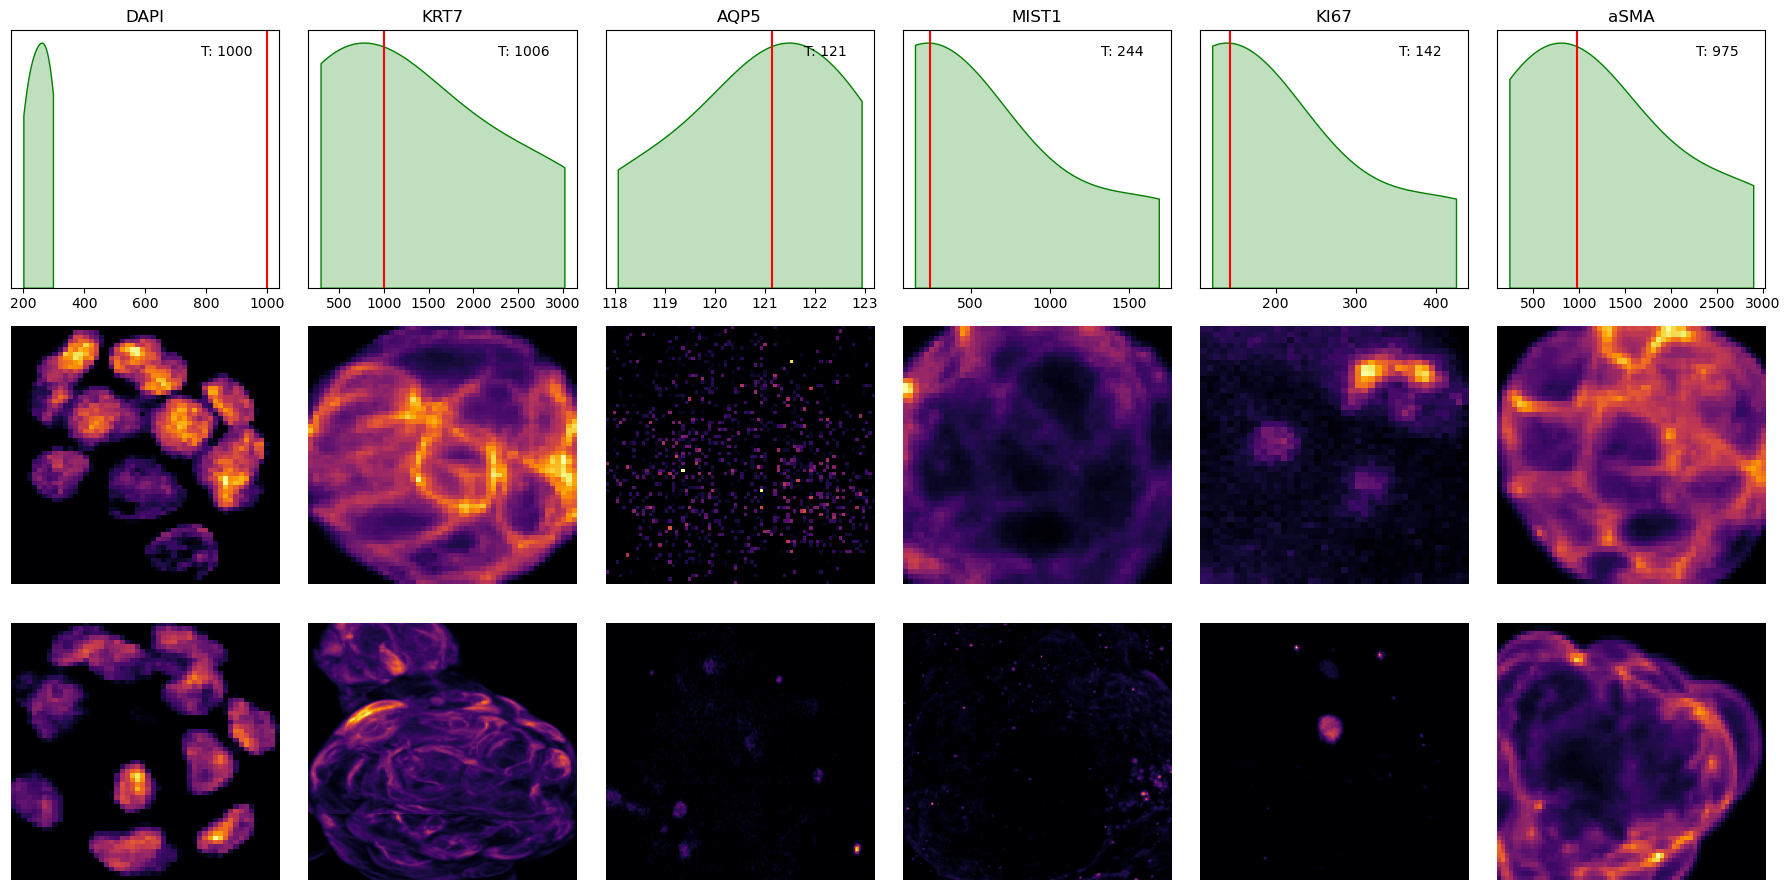

In [9]:
fig = plot_thresholds(
    thresholds = thresholds, 
    dict_org = dict_org, 
    timepoints_lst = timepoints_lst,
    ome_zarr_dict = ome_zarr_dict,
    table_name = table_name,
    label_name = label_name,
    seed = 0
    )

# Visualize segmentation fidelity
Loads two random wells of every plate and overlays it with its segmentation mask to check for segmentation fidelity.

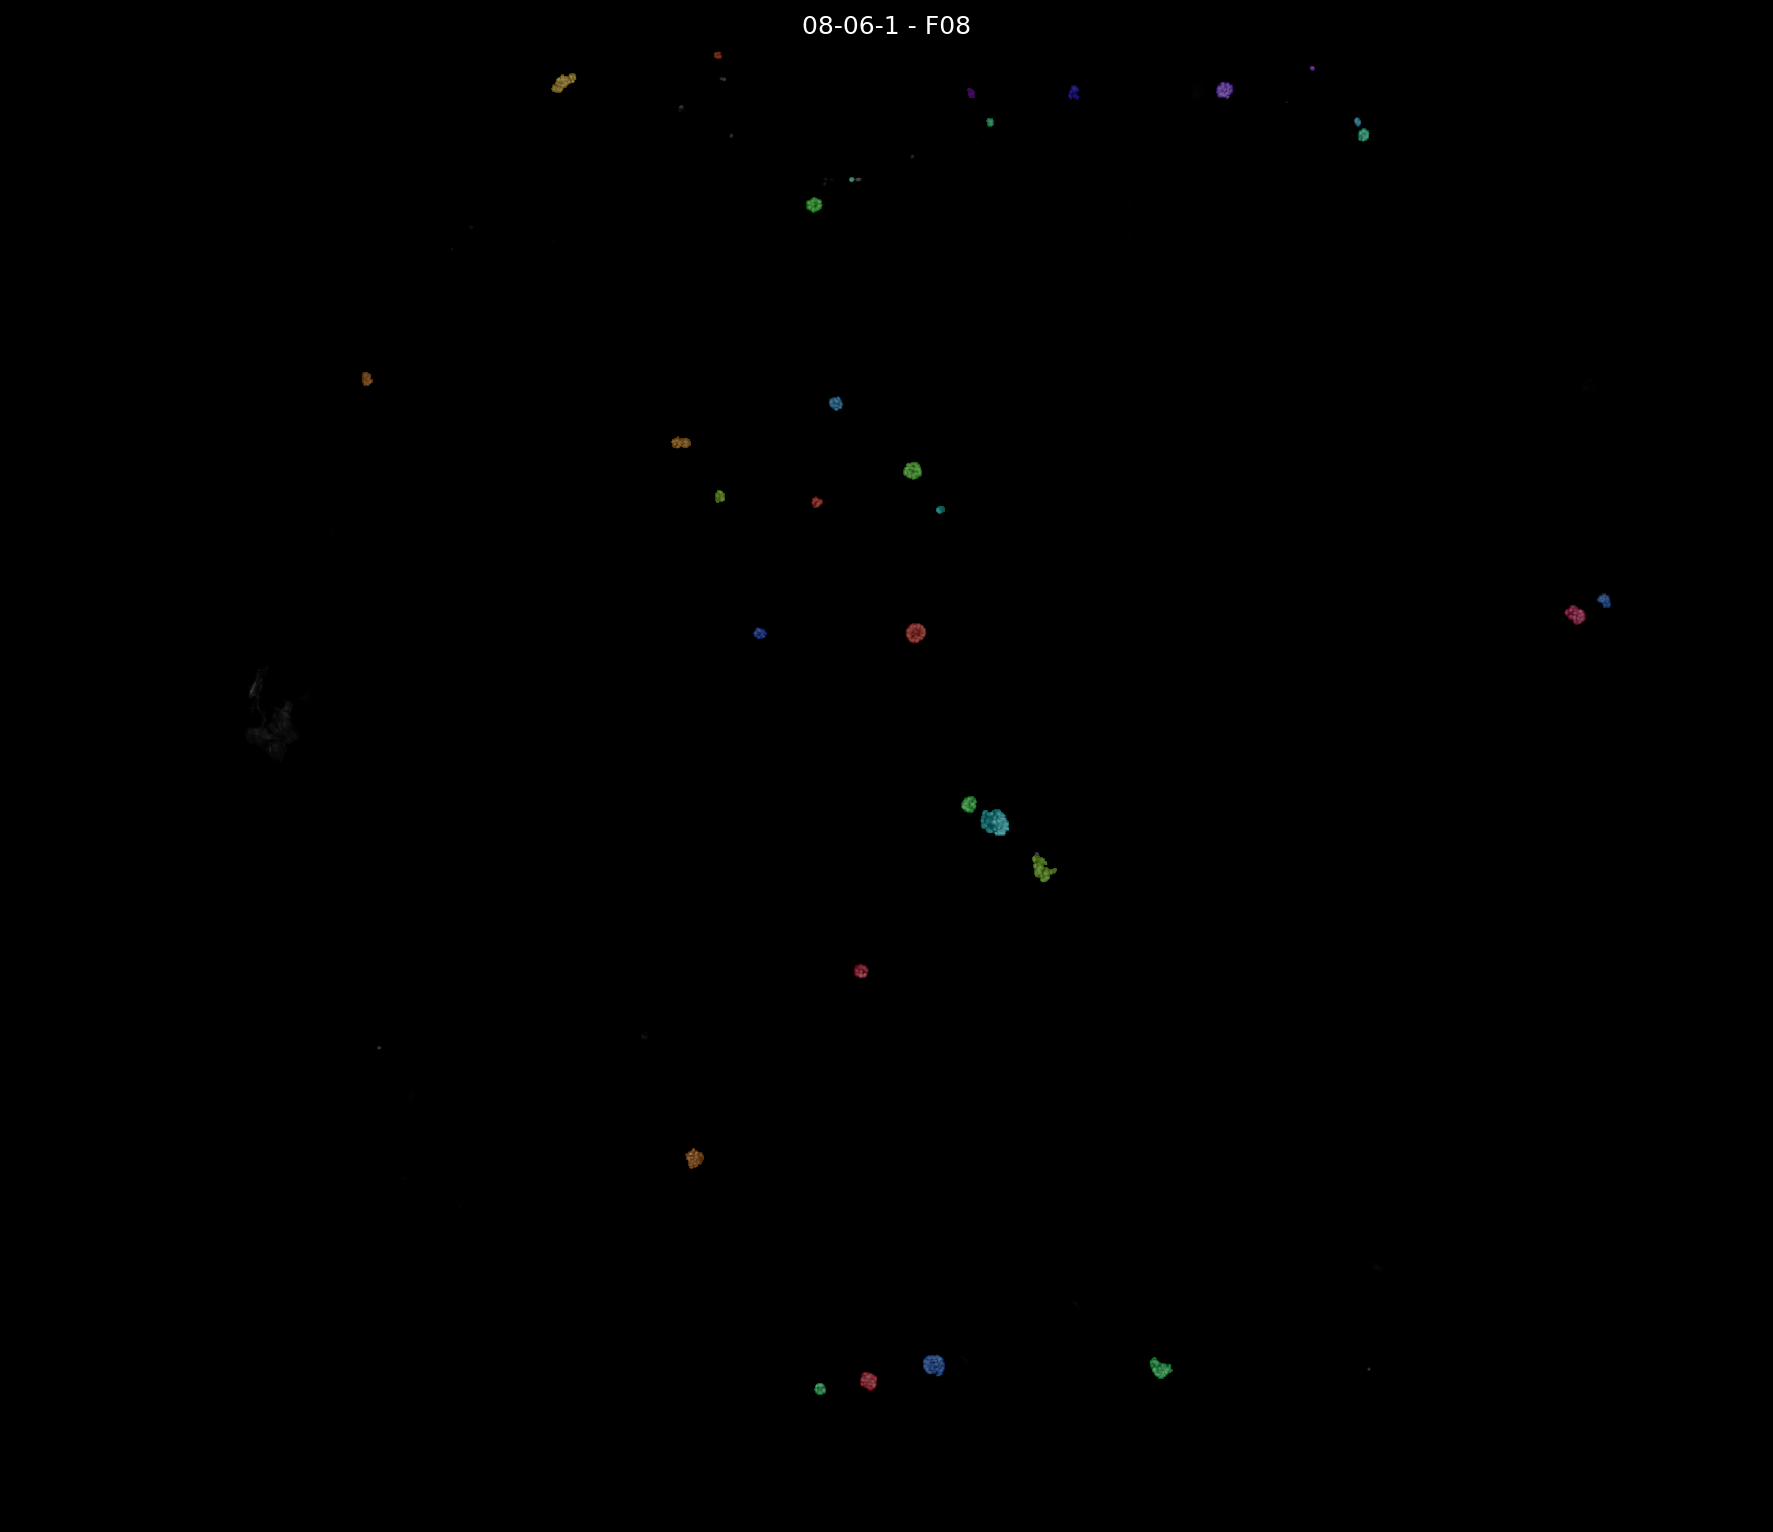

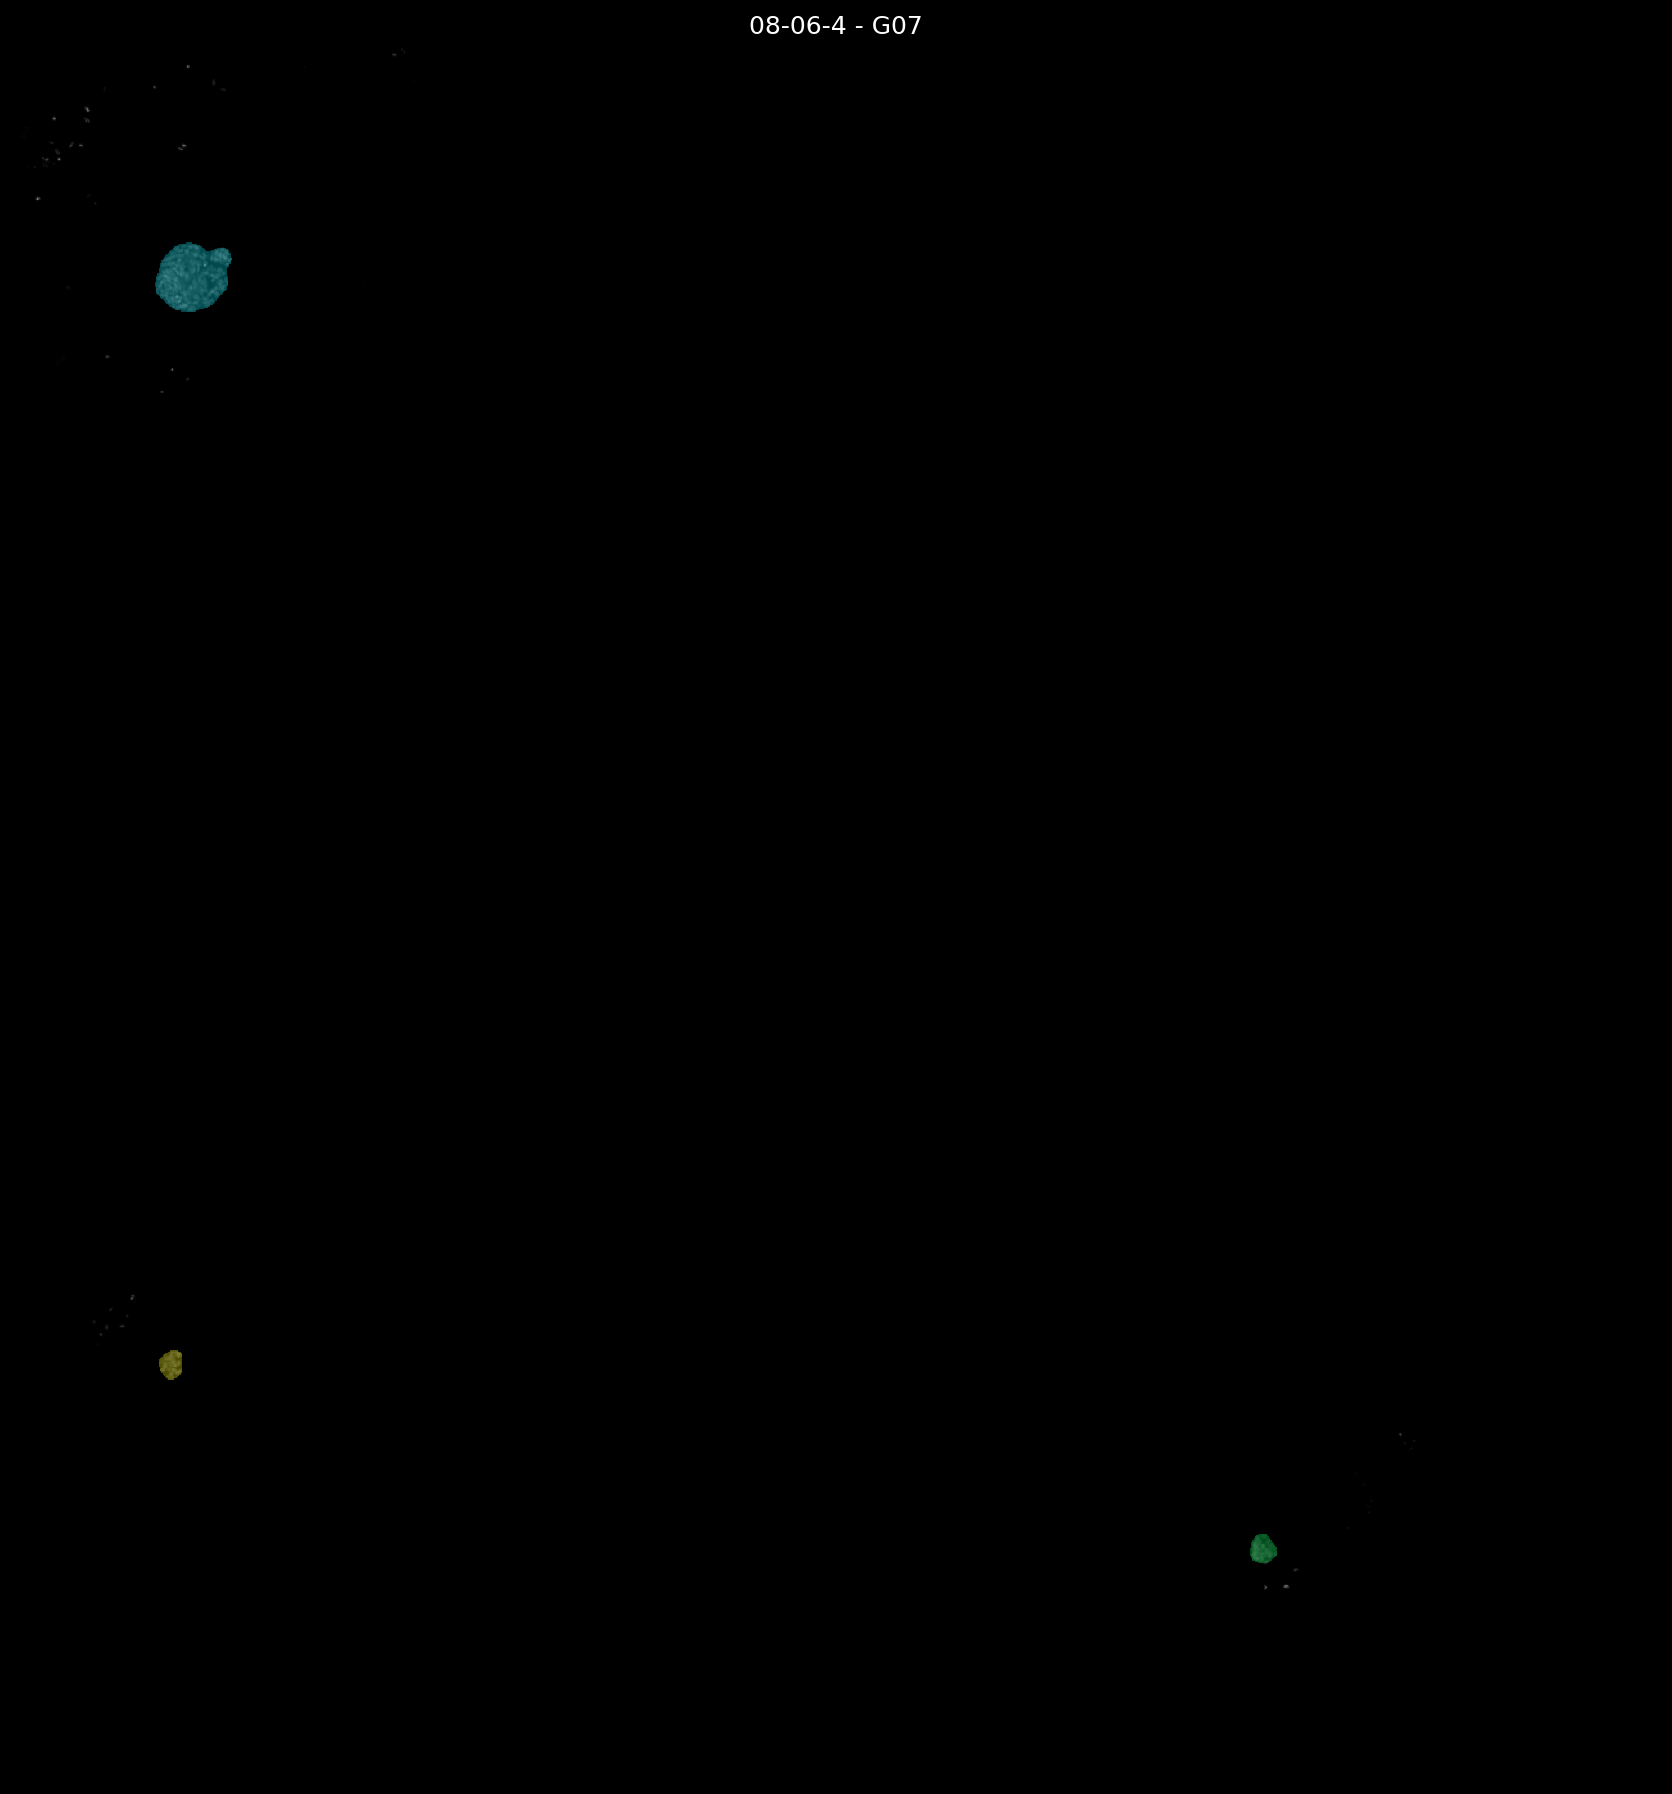

In [10]:
channel = [0] # Channel to plot. Related to order of stainings in "stainings" dictionary.
channel_colors = ["Gray"] # Color of channel to plot.
channel_ranges = [[100,4000]] # Range of values to plot for channel. Must
n = 1 # Number of wells to plot per timepoint.
pyriamid_lvl_plot = 2 # OME_zarr Pyramid level to plot.

segmentation_fidelity_check(
    ome_zarr_dict, 
    channels = channel,
    channel_colors = channel_colors,
    channel_ranges = channel_ranges,
    n = n,
    label_name = label_name,
    pyramid_lvl_plot = pyriamid_lvl_plot
    )

# Test of crypt features extraction

Used to test parameters important to extract crypt features, such as sigm_skeleton, n_angle_determination, and radius_multiplier. Set parameters will be used in a subsequent step for feature extraction. Will show found crypts as well as an approximate for the non-crpyt region marked by a circle on n random organoids per plate.

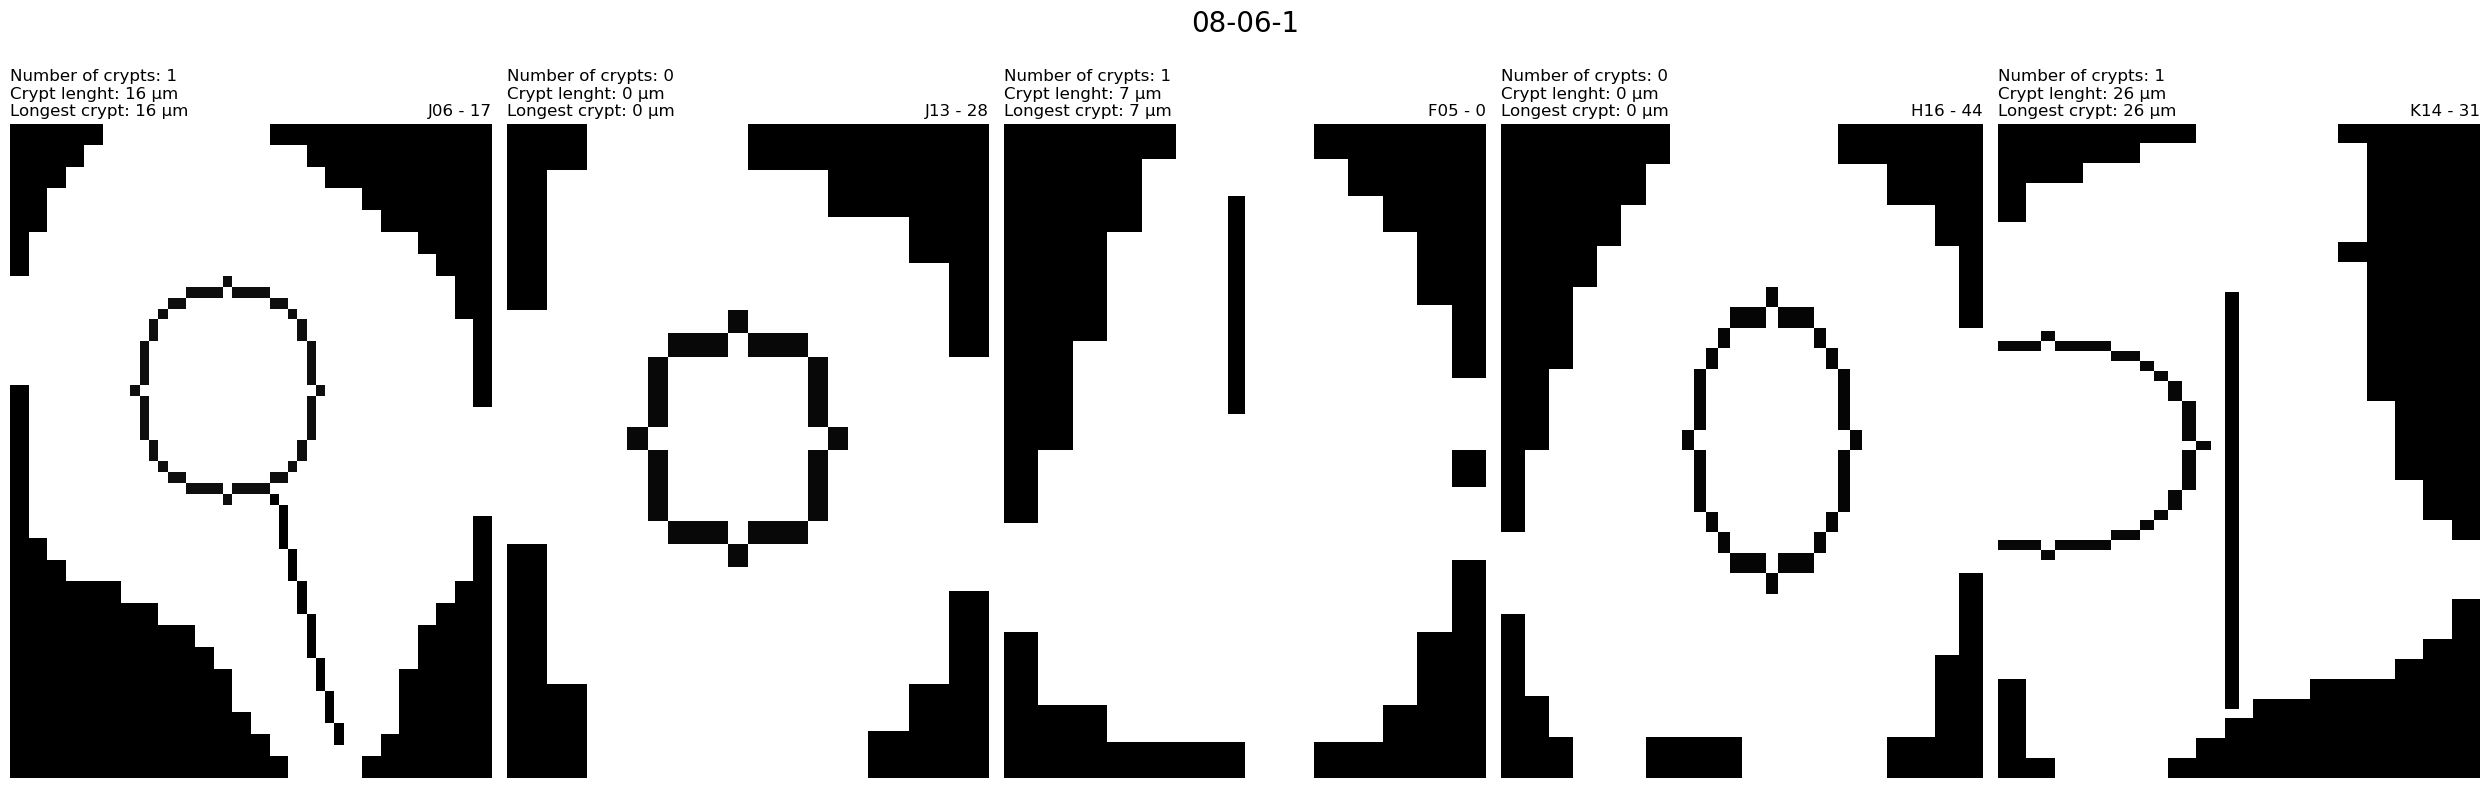

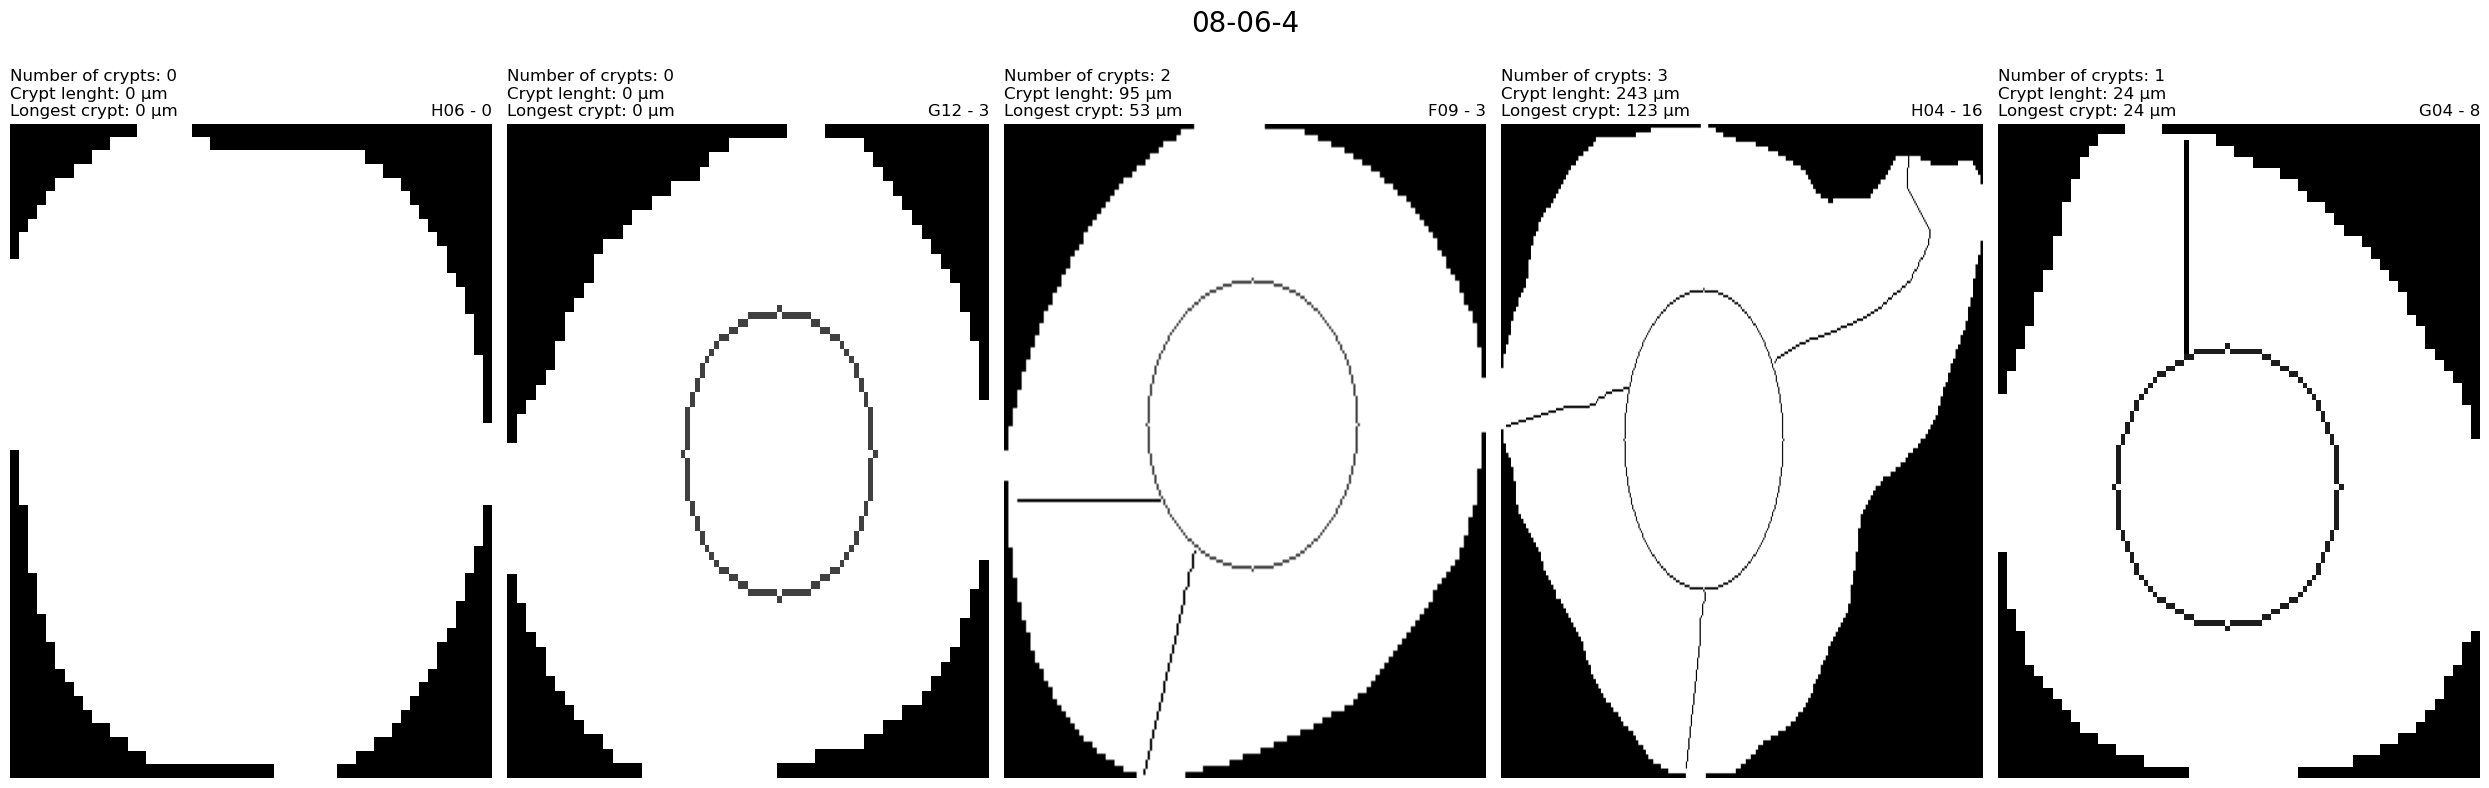

In [11]:
sigma_skeleton = 3 # Integer. Sigma for gaussian blurring of mask before skeletonization. Sharp segmentation edges may lead to difficulties, necessating higher sigma_skeleton numbers.
n_angle_determination = 50 # Integer. Number of pixel used at the end of each branch to estimate its direction until the segmentation border. If the number is higher than the length of the branch, the whole branch will be used instead.
radius_multiplier = 0.5 # Float. Multiplier of maximum-inscribed-circle radius to estimate crypt-free region. The lower the number, the more sensititve the algorithm is to smaller crypts.
n = 5 # Integer. Number of randomly chosen organoids per imaging plate.
seed = 0 # Integer. Random seed.

test_skeletonization(
    barcodes,
    ome_zarr_dict,
    ome_zarr_df,
    table_name = table_name,
    label_name = label_name,
    pyramid_level = pyramid_level,
    n = n,
    seed = seed, 
    sigma_skeleton = sigma_skeleton, 
    n_angle_determination = n_angle_determination, 
    radius_multiplier = radius_multiplier
)

# Extract Features

Function extracts morphological and staining features from all segmented organoids within the source+folder structure. Results will be saved in an .csv and .h5ad file in the analysis_dir+"2_Results"+result_file_name. .h5ad output of this function should be used as an input for the subsequent notebook "2_Filtering". 

In [12]:
images = extract_features(
    ome_zarrs_dict = ome_zarr_dict, 
    ome_zarrs_df = ome_zarr_df,
    table_name = table_name, 
    label_name = label_name, 
    pyramid_level = pyramid_level,
    source = source,
    folder = folder,
    analysis_dir = analysis_dir,
    barcodes = barcodes,
    experiment_setup = experiment_setup,
    thresholds = thresholds,
    stainings = stainings,
    result_file_name = "1_FeatureExtraction",
    radius_multiplier = radius_multiplier,
    sigma_skeleton = sigma_skeleton,
    quantiles_to_calc = quantiles_to_calc
    )

Barcodes:   0%|          | 0/2 [00:00<?, ?it/s]

Wells (08-06-1):   0%|          | 0/125 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
stainings[experiment_setup["-".join("08-06-1-E03-0".split("-")[:-2])]["08-06-1-E03-0".split("-")[-2]][1]]

In [ ]:
f = folder[0]

In [ ]:
from ez_zarr import ome_zarr

plate = ome_zarr.import_plate(f)

In [ ]:
plate.images[0].plot(label_name = "organoids", pyramid_level= 0, scalebar_micrometer=50, show_scalebar_label=True, label_value= 21, channels=[0],fig_width_inch=2.0, fig_height_inch=2.0)

In [ ]:
ome_zarr_df

In [ ]:
well = "E03"
barcode = "08-06-1"

img = ome_zarr_dict[barcode].images[1]

In [ ]:
from skimage import io
arr = img.get_array_by_coordinate(pyramid_level=0, as_NumPy=True, label_name="organoids")
io.imshow(arr[0])

In [ ]:
img.get_bounding_box_for_label_value(label_name='organoids', label_value=1, label_pyramid_level=0, pyramid_level_output = 0, extend_pixels=50)

In [ ]:
arr.shape

In [ ]:
upleft, lowright = img.get_bounding_box_for_label_value(label_name='organoids', label_value=1, label_pyramid_level=0, pyramid_level_output = 0)
upleft = tuple(ti/2 for ti in upleft)
lowright = tuple(ti/2 for ti in lowright)
a = img.get_array_by_coordinate(label_name = "organoids", as_NumPy=True, pyramid_level=0, upper_left_yx=upleft[1:], lower_right_yx=lowright[1:], coordinate_unit="pixel")
io.imshow(a[0])

In [ ]:
int, lab = img.get_array_pair_by_coordinate(label_name = 'organoids', pyramid_level = 0)

In [ ]:
lab["organoids"].shape

In [ ]:
int.shape

In [ ]:
io.imshow(lab["organoids"][0], cmap="gray")

In [ ]:
upleft, lowright = img.get_bounding_box_for_label_value(label_name='organoids', label_value=1, label_pyramid_level = 0, pyramid_level_output= 1)
upleft #why three values?

In [ ]:
a = img.get_array_by_coordinate(label_name = "organoids", as_NumPy=True, pyramid_level = 0, upper_left_yx=upleft[1:], lower_right_yx=lowright[1:], coordinate_unit="pixel") #why cant pyramid_level_ouotput not be same as pyramid level here?
io.imshow(a[0])

In [ ]:
tbl = well_ov.get_table("organoids_ROI_table")

In [ ]:
tbl

In [ ]:
upperleft = (tbl.iloc[0]["y_micrometer"], tbl.iloc[0]["x_micrometer"])
upperleft

In [ ]:
lowerright = (tbl.iloc[0]["y_micrometer"]+tbl.iloc[0]["len_y_micrometer"], tbl.iloc[0]["x_micrometer"]+tbl.iloc[0]["len_x_micrometer"])
lowerright

In [ ]:
a,b  = well_ov.get_array_pair_by_coordinate(label_name = label_name, pyramid_level = 0, upper_left_yx=upperleft, lower_right_yx=lowerright) #why cant pyramid_level_ouotput not be same as pyramid level here?

In [ ]:
b[label_name].shape

In [ ]:
io.imshow(a[3][0])

In [ ]:
experiment_setup[bc].keys()

In [ ]:
# Loop through BCs
for bc in ome_zarr_dict.keys(): # Loop through barcodes
    plate = ome_zarr_dict[bc]

    for i, well in enumerate(plate.get_names()): # Loop through wells in barcode

        if well in experiment_setup[bc].keys(): # Check if well is part of experiment

            well_ov = plate.images[i]
            table = well_ov.get_table(table_name)

            if table.empty:
                print(f"No table {table_name} for well {well} in barcode {bc}. Skipping.")
                continue

            print(f"Processing well {well} in barcode {bc}")
            for i in range(len(table)):

                img, mask  = well_ov.get_array_pair_by_coordinate(
                    label_name = label_name, 
                    pyramid_level = pyramid_level,
                    upper_left_yx = (table.iloc[i]["y_micrometer"], table.iloc[i]["x_micrometer"]),
                    lower_right_yx = (table.iloc[i]["y_micrometer"]+table.iloc[i]["len_y_micrometer"], table.iloc[i]["x_micrometer"]+table.iloc[i]["len_x_micrometer"])
                    )
            
                UID = f"{bc}-{well}-{row_idx}" # Unique ID for well and barcode 

In [ ]:
for bc in ome_zarr_dict.keys():
    plate = ome_zarr_dict[bc]
    well_names = plate.get_names()
    exp_wells = experiment_setup[bc]

    for well_idx, well in enumerate(well_names):
        if well not in exp_wells:
            continue

        well_ov = plate.images[well_idx]
        table = well_ov.get_table(table_name)

        if table.empty:
            print(f"No table {table_name} for well {well} in barcode {bc}. Skipping.")
            continue

        print(f"Processing well {well} in barcode {bc}")

        for row_idx, row in table.iterrows():

            img, mask = well_ov.get_array_pair_by_coordinate(
                label_name = label_name,
                pyramid_level = pyramid_level,
                upper_left_yx = (row["y_micrometer"], row["x_micrometer"]),
                lower_right_yx = (row["y_micrometer"]+row["len_y_micrometer"], row["x_micrometer"]+row["len_x_micrometer"])
            )

            UID = f"{bc}-{well}-{row_idx}"
            # Further processing for img, mask, and UID


In [ ]:
row_idx

In [ ]:
well_ov = plate.images[10]

In [ ]:
io.imshow(img[1][0])

In [ ]:
def load_img_mask_by_UID(UID, ome_zarr_dict, table_name, label_name, pyramid_level, channel):
    """
    Retrieve an image and corresponding mask for a specific entry in an OME-Zarr plate dataset,
    based on a unique identifier (UID) and additional parameters.

    Parameters:
        UID (str): Unique identifier of the data instance, formatted as 'barcode-well-index'.
        ome_zarr_dict (dict): Dictionary mapping barcodes to Plate objects, assumed to adhere to an OME-Zarr interface.
        table_name (str): Name of the table to extract entries from for the well (e.g., 'organoids').
        label_name (str): Name of the label within the mask to extract (e.g., 'organoid').
        pyramid_level (int): Pyramid level to extract the image/mask from.
        channel (int): Index of the channel to extract from the image.
    """

    # UID format: 'barcode-well-index'
    try:
        index_str = UID.split('-')[-1]
        bc = "-".join(UID.split('-')[:-2])
        well = UID.split('-')[-2]

        index = int(index_str)

    except Exception as e:
        raise ValueError(f"UID format error: {UID} should be 'barcode-well-index'") from e

    # Check if barcode exists
    if bc not in ome_zarr_dict:
        raise KeyError(f"Barcode {bc} not found in ome_zarr_dict.")
    plate = ome_zarr_dict[bc]

    # Check if well exists
    well_names = plate.get_names()
    if well not in well_names:
        raise KeyError(f"Well {well} not found in barcode {bc}.")

    # Retrieve well object
    well_idx = well_names.index(well)
    well_ov = plate.images[well_idx]

    # Retrieve table and check existence
    table = well_ov.get_table(table_name)
    if table.empty:
        raise ValueError(f"Table {table_name} is empty for well {well} in barcode {bc}.")

    # Check if index is valid
    if index < 0 or index >= len(table):
        raise IndexError(f"Index {index} out of bounds for table length {len(table)}")
    


    # Get row and coordinates
    entry = table.iloc[index]
    ul_y, ul_x = entry["y_micrometer"], entry["x_micrometer"]
    lr_y = ul_y + entry["len_y_micrometer"]
    lr_x = ul_x + entry["len_x_micrometer"]

    # Retrieve image and mask
    img, mask = well_ov.get_array_pair_by_coordinate(
        label_name=label_name,
        pyramid_level=pyramid_level,
        upper_left_yx=(ul_y, ul_x),
        lower_right_yx=(lr_y, lr_x)
    )

    # Check if label exists in mask
    if label_name not in mask:
        raise KeyError(f"Label {label_name} not found in mask for well {well} in barcode {bc}.")
    
    # Check if channel is valid
    if channel < 0 or channel >= img.shape[0]:
        raise IndexError(f"Channel {channel} out of bounds for image with {img.shape[0]} channels.")

    img = img[channel, 0]  # Select specific channel

    mask = mask[label_name][0]
    mask[mask != index+1] = 0  # Remove other labels than current organoid

    return img, mask

img, mask = load_img_mask_by_UID("08-06-1-E09-9", ome_zarr_dict, table_name, label_name, pyramid_level, 3)
io.imshow(mask)


In [ ]:
mask["organoids"][0][mask["organoids"][0] != 16] = 0 

In [ ]:
io.imshow(mask["organoids"][0])

In [ ]:
from skimage import measure
from skimage import io
import numpy as np


In [ ]:
index_str = UID.split('-')[-1]
index = int(index_str)

In [ ]:
int(index_str)

In [ ]:
int

In [ ]:
plate.get_names().index("E03")  # Example to find index of well "E03" in plate names

In [ ]:
img.shape[0]

In [ ]:
img[0, 0]

In [ ]:
well_ov

In [ ]:
plate.get_scale(pyramid_level='0')[-1]

In [ ]:
ome_zarr_dict["08-06-1"].get_pixel_spacing(pyramid_level=pyramid_level)  # Get pixel spacing for the specified pyramid level

In [ ]:
ome_zarr_dict["08-06-1"].get_pixel_spacing(pyramid_level=pyramid_level)

In [ ]:
ome_zarr_dict["08-06-1"][0].get_scale(pyramid_level='0')[-1]

In [ ]:
images = {"C01": 1, "C02": 2, "C03": 3, "C04": 4, "C05": 5, "Mask": None}

In [ ]:
images[0]